# klastering email

In [1]:
!pip install plotly


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
!pip install -q nltk contractions emoji pyspellchecker Sastrawi


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [3]:
!pip install gensim



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [4]:
import re
import sys
import time
import string
import warnings
from collections import Counter
import pandas as pd
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from spellchecker import SpellChecker
import contractions
import emoji
from gensim.models import Word2Vec, FastText
from gensim import corpora, models
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from tqdm import tqdm
warnings.filterwarnings('ignore')

In [5]:
nltk.download("punkt")
nltk.download("punkt_tab")

# Download stopwords
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/codespace/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
berita = pd.read_csv("spam.csv", dtype=str, encoding="utf-8", encoding_errors="ignore").fillna("")
berita.head()


,id,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,1,"Go until jurong point, crazy.. Available only ...",,,
1,2,Ok lar... Joking wif u oni...,,,
2,3,Free entry in 2 a wkly comp to win FA Cup fina...,,,
3,4,U dun say so early hor... U c already then say...,,,
4,5,"Nah I don't think he goes to usf, he lives aro...",,,


In [15]:
import string

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = emoji.demojize(text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\W', ' ', text)
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r'\s+', ' ', text).strip()
    return text


In [16]:
df_raw = pd.read_csv(
    "spam.csv",
    header=None,
    encoding="latin1",
    on_bad_lines="skip"
)

# ambil hanya dua kolom pertama: id + text
df = pd.DataFrame({
    "id": df_raw.iloc[:, 0],
    "Text": df_raw.iloc[:, 1]
})

# hapus baris kosong
df = df.dropna(subset=["Text"])

df.head()

,id,Text
0,id,Text
1,1,"Go until jurong point, crazy.. Available only ..."
2,2,Ok lar... Joking wif u oni...
3,3,Free entry in 2 a wkly comp to win FA Cup fina...
4,4,U dun say so early hor... U c already then say...


In [17]:
df["Clean"] = df["Text"].apply(clean_text)
df.head()


,id,Text,Clean
0,id,Text,text
1,1,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
2,2,Ok lar... Joking wif u oni...,ok lar joking wif u oni
3,3,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
4,4,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say


In [18]:
tfidf = TfidfVectorizer(stop_words='english')
X = tfidf.fit_transform(df["Clean"])
X.shape


(5573, 8296)

In [21]:
df.to_csv("hasil_preprocessing_emailUTS.csv", index=False)


In [22]:
# Memuat Dataset
try:
    df = pd.read_csv('hasil_preprocessing_emailUTS.csv')
    print(f"\nDataset berhasil dimuat. Jumlah data: {len(df)} baris.")
    print("Contoh data awal:")
    print(df.head())
except FileNotFoundError:
    print("\nError: File tidak ditemukan. Pastikan nama file CSV sudah benar.")
    # Jika file tidak ditemukan, hentikan proses.
    # df = pd.DataFrame()


Dataset berhasil dimuat. Jumlah data: 5573 baris.
Contoh data awal:
   id                                               Text  \
0  id                                               Text   
1   1  Go until jurong point, crazy.. Available only ...   
2   2                      Ok lar... Joking wif u oni...   
3   3  Free entry in 2 a wkly comp to win FA Cup fina...   
4   4  U dun say so early hor... U c already then say...   

                                               Clean  
0                                               text  
1  go until jurong point crazy available only in ...  
2                            ok lar joking wif u oni  
3  free entry in a wkly comp to win fa cup final ...  
4        u dun say so early hor u c already then say  


In [24]:
def safe_tokenize(text):
    if not isinstance(text, str):
        text = ""  
    return word_tokenize(text)

df['tokens'] = df['Clean'].apply(safe_tokenize)
print(f"Data bersih dimuat. Jumlah data: {len(df)} baris.")


Data bersih dimuat. Jumlah data: 5573 baris.


Jumlah dokumen valid: 5570

Kamus dibuat. Jumlah kata unik setelah filter: 3904

--- Menjalankan HDP untuk estimasi jumlah topik... ---
Perkiraan kasar jumlah topik dari HDP: 20

Searching topik dari 2 sampai 15...
Jumlah topik: 2 | Koherensi: 0.5028
Jumlah topik: 3 | Koherensi: 0.5044
Jumlah topik: 4 | Koherensi: 0.5328
Jumlah topik: 5 | Koherensi: 0.5398
Jumlah topik: 6 | Koherensi: 0.5092
Jumlah topik: 7 | Koherensi: 0.5510
Jumlah topik: 8 | Koherensi: 0.5162
Jumlah topik: 9 | Koherensi: 0.5248
Jumlah topik: 10 | Koherensi: 0.5121
Jumlah topik: 11 | Koherensi: 0.4967
Jumlah topik: 12 | Koherensi: 0.5300
Jumlah topik: 13 | Koherensi: 0.5134
Jumlah topik: 14 | Koherensi: 0.5175


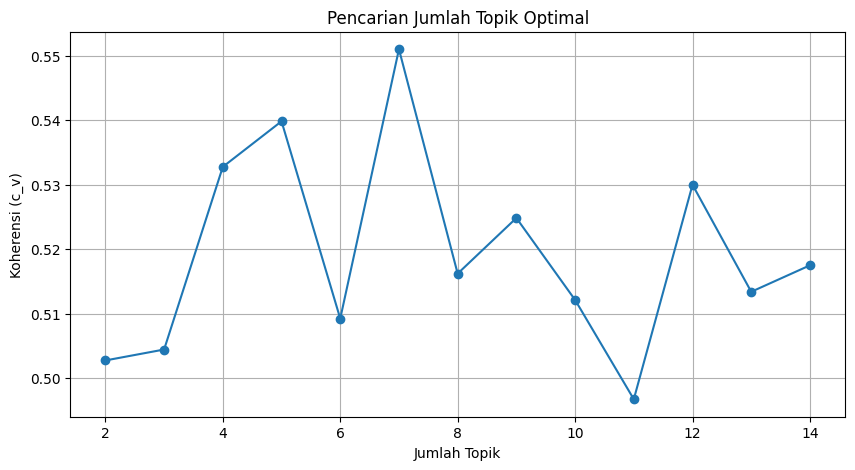


🔥 Jumlah topik optimal: 7

--- Melatih LDA final... ---

--- Topik yang ditemukan ---

Topik 0: 0.026*"is" + 0.026*"to" + 0.022*"u" + 0.022*"a" + 0.022*"it" + 0.018*"he" + 0.016*"i" + 0.015*"but" + 0.011*"who" + 0.009*"all"

Topik 1: 0.046*"u" + 0.040*"i" + 0.021*"ok" + 0.018*"me" + 0.016*"lor" + 0.015*"now" + 0.014*"call" + 0.013*"then" + 0.012*"go" + 0.011*"can"

Topik 2: 0.048*"to" + 0.021*"a" + 0.019*"your" + 0.018*"call" + 0.015*"for" + 0.015*"and" + 0.014*"the" + 0.014*"å" + 0.013*"is" + 0.011*"you"

Topik 3: 0.062*"you" + 0.050*"i" + 0.033*"to" + 0.022*"the" + 0.020*"and" + 0.018*"me" + 0.014*"that" + 0.013*"are" + 0.011*"my" + 0.010*"do"

Topik 4: 0.038*"the" + 0.024*"is" + 0.022*"for" + 0.022*"a" + 0.017*"and" + 0.017*"you" + 0.016*"to" + 0.013*"ltgt" + 0.013*"your" + 0.013*"i"

Topik 5: 0.040*"a" + 0.036*"in" + 0.029*"my" + 0.021*"i" + 0.020*"u" + 0.017*"of" + 0.016*"the" + 0.013*"ltgt" + 0.011*"is" + 0.011*"good"

Topik 6: 0.047*"to" + 0.026*"call" + 0.025*"a" + 0.023*"free

In [26]:
from gensim.corpora import Dictionary
from gensim.models import HdpModel, LdaMulticore
import time
import matplotlib.pyplot as plt
import numpy as np
from gensim.models.coherencemodel import CoherenceModel

# Pastikan tidak ada dokumen kosong
documents = [doc for doc in df['tokens'].tolist() if len(doc) > 0]

print(f"Jumlah dokumen valid: {len(documents)}")

# Buat dictionary
dictionary = Dictionary(documents)

# Filter extremes SESUAI dataset kecil
dictionary.filter_extremes(no_below=2, no_above=0.9)

# Buat corpus
corpus = [dictionary.doc2bow(doc) for doc in documents]

print(f"\nKamus dibuat. Jumlah kata unik setelah filter: {len(dictionary)}")

# ===== HDP untuk estimasi topik =====
print("\n--- Menjalankan HDP untuk estimasi jumlah topik... ---")

hdp_model = HdpModel(corpus=corpus, id2word=dictionary)

# Ambil topik yang non-empty
hdp_topics = hdp_model.print_topics()

estimated_num_topics = len(hdp_topics)

print(f"Perkiraan kasar jumlah topik dari HDP: {estimated_num_topics}")


# ===== CARI JUMLAH TOPIK TERBAIK =====
def compute_coherence_values(dictionary, corpus, texts, start, limit, step):
    coherence_values = []
    for num_topics in range(start, limit, step):
        model = LdaMulticore(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            passes=8,
            random_state=42,
            workers=1  # aman untuk semua device
        )
        coherencemodel = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        coherence_values.append(coherencemodel.get_coherence())
        print(f"Jumlah topik: {num_topics} | Koherensi: {coherence_values[-1]:.4f}")
    return coherence_values

# Range pencarian disesuaikan data kecil
search_start = 2
search_limit = min(estimated_num_topics + 4, 15)  # batas aman
search_step = 1

print(f"\nSearching topik dari {search_start} sampai {search_limit}...")

coherence_values = compute_coherence_values(
    dictionary=dictionary,
    corpus=corpus,
    texts=documents,
    start=search_start,
    limit=search_limit,
    step=search_step
)

x = range(search_start, search_limit, search_step)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x, coherence_values, marker='o')
plt.xlabel('Jumlah Topik')
plt.ylabel('Koherensi (c_v)')
plt.grid(True)
plt.title("Pencarian Jumlah Topik Optimal")
plt.show()

optimal_num_topics = x[np.argmax(coherence_values)]
print(f"\n🔥 Jumlah topik optimal: {optimal_num_topics}")


# ===== LDA FINAL =====
print("\n--- Melatih LDA final... ---")

lda_model = LdaMulticore(
    corpus=corpus,
    id2word=dictionary,
    num_topics=optimal_num_topics,
    passes=15,
    random_state=42,
    workers=1
)

print("\n--- Topik yang ditemukan ---")
for idx, topic in lda_model.print_topics(num_words=10):
    print(f"\nTopik {idx}: {topic}")


# ===== EKSTRAK FITUR TOPIK =====
def get_lda_features(lda_model, bow_corpus, n_topics):
    features = []
    for doc_bow in bow_corpus:
        dist = lda_model.get_document_topics(doc_bow, minimum_probability=0)
        vector = [0.0] * n_topics
        for topic_id, prob in dist:
            vector[topic_id] = prob
        features.append(vector)
    return np.array(features)

X = get_lda_features(lda_model, corpus, optimal_num_topics)

print("\nEkstraksi fitur selesai!")
print(f"Bentuk matriks fitur X: {X.shape}")


Jumlah baris df: 5573
Jumlah baris X : 5570
⚠️ Jumlah baris tidak sama, memperbaiki...
✅ Sekarang jumlah baris df = 5570

--- Mencari K Optimal dengan Silhouette Score ---
Untuk K=2, Silhouette Score = 0.3051
Untuk K=3, Silhouette Score = 0.3631
Untuk K=4, Silhouette Score = 0.4085


Untuk K=5, Silhouette Score = 0.4440
Untuk K=6, Silhouette Score = 0.4865
Untuk K=7, Silhouette Score = 0.5213
Untuk K=8, Silhouette Score = 0.4512
Untuk K=9, Silhouette Score = 0.4545
Untuk K=10, Silhouette Score = 0.4233
Untuk K=11, Silhouette Score = 0.4278
Untuk K=12, Silhouette Score = 0.4079
Untuk K=13, Silhouette Score = 0.4102
Untuk K=14, Silhouette Score = 0.4582
Untuk K=15, Silhouette Score = 0.4585


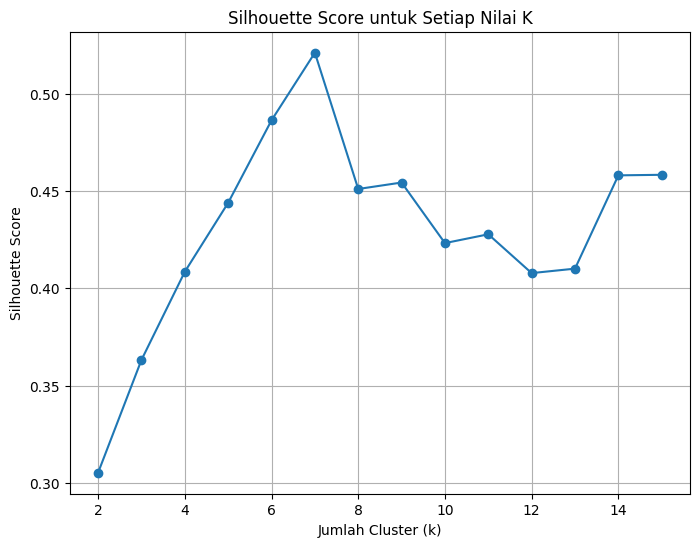


🔥 Berdasarkan Silhouette Score, K terbaik adalah: 7

--- Menjalankan K-Means Final dengan K=7 ---

Cluster selesai dibuat!
cluster
1    2053
3     894
6     636
2     586
5     567
4     418
0     416
Name: count, dtype: int64

==== Contoh Email Tiap Cluster ====

=== CLUSTER 0 ===
- XXXMobileMovieClub: To use your credit, click the WAP link in the next txt message or click here>> http://wap. xxxmobilemovieclub.com?n=QJKGIGHJJGCBL...
- Is that seriously how you spell his name?...
- IÛ÷m going to try for 2 months ha ha only joking...

=== CLUSTER 1 ===
- Nah I don't think he goes to usf, he lives around here though...
- FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv...
- Even my brother is not like to speak with me. They treat me like aids patent....

=== CLUSTER 2 ===
- I've been searching for the right words to thank you for this breather. I promise i wont take your help for granted

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np


print("Jumlah baris df:", len(df))
print("Jumlah baris X :", X.shape[0])

if len(df) != len(X):
    print("⚠️ Jumlah baris tidak sama, memperbaiki...")
    df = df.iloc[:len(X)].reset_index(drop=True)
    print("✅ Sekarang jumlah baris df =", len(df))
else:
    print("Jumlah baris sudah sama.")


# ================================
# ✔️ Mencari K Optimal
# ================================

print("\n--- Mencari K Optimal dengan Silhouette Score ---")

K_range = range(2, min(16, len(X)))  # aman untuk dataset kecil
silhouette_scores = []

for k in K_range:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    labels = kmeans_model.labels_
    
    # Cek jika hanya 1 cluster unik → silhouette error
    if len(set(labels)) == 1:
        print(f"K = {k} dilewati (hanya 1 cluster)")
        silhouette_scores.append(-1)
        continue

    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f"Untuk K={k}, Silhouette Score = {score:.4f}")


# ================================
# ✔️ Plot Silhouette Score
# ================================

plt.figure(figsize=(8, 6))
plt.plot(list(K_range), silhouette_scores, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score untuk Setiap Nilai K')
plt.grid(True)
plt.show()


# ================================
# ✔️ Menentukan K Terbaik
# ================================

optimal_k = list(K_range)[np.argmax(silhouette_scores)]
print(f"\n🔥 Berdasarkan Silhouette Score, K terbaik adalah: {optimal_k}")


# ================================
# ✔️ Latih Model Final
# ================================

print(f"\n--- Menjalankan K-Means Final dengan K={optimal_k} ---")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

print("\nCluster selesai dibuat!")
print(df['cluster'].value_counts())


# ================================
# ✔️ Contoh Email tiap Cluster
# ================================

print("\n==== Contoh Email Tiap Cluster ====")
for i in range(optimal_k):
    print(f"\n=== CLUSTER {i} ===")
    contoh = df[df['cluster'] == i]['Text'].head(3).tolist()
    for isi in contoh:
        print("- " + str(isi)[:200] + "...")
